# Week 9: SOP EEG Pipeline (End-to-End)

This notebook implements the DSP SOP from first principles using the EDF data in `project/notebooks/week9/data/EEG_DATA.edf`.
Figures are saved to `project/notebooks/week9/figures/`.

## 1) Imports and configuration

In [33]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Add project/src to path for local imports
import sys
import importlib
repo_root = Path.cwd().parents[2]
sys.path.append(str(repo_root / 'project' / 'src'))

import eeg_io
import window_math
import transform_logic
import stft_engine

importlib.reload(eeg_io)
importlib.reload(window_math)
importlib.reload(transform_logic)
importlib.reload(stft_engine)

from eeg_io import load_channel_edf
from window_math import get_window, window_energy
from transform_logic import dft_one_sided, frequency_bins, periodogram
from stft_engine import stft_psd

DATA_PATH = repo_root / 'project' / 'notebooks' / 'week9' / 'data' / 'EEG_DATA.edf'
FIG_DIR = repo_root / 'project' / 'notebooks' / 'week9' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Phase 1: Knowledge-gathering (known signals)

## 4) DFT intuition: same vs different phase

We compare sums of equal-frequency sines with the same phase and a 90° phase shift.

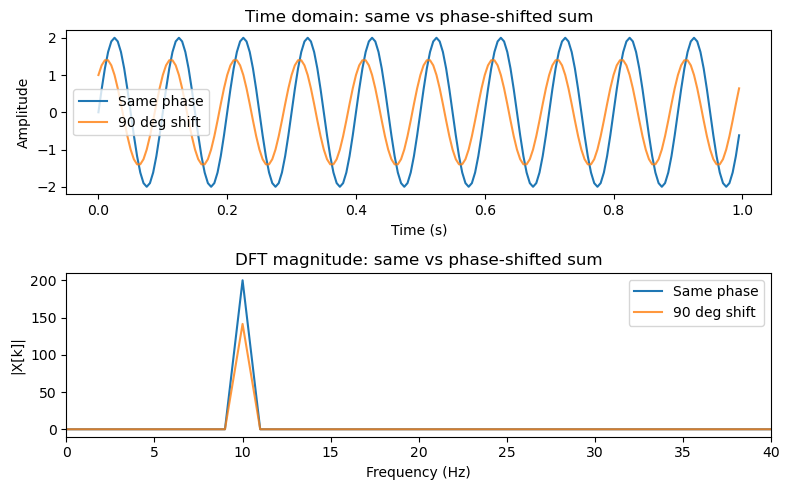

In [34]:
fs_demo = 200.0
t_demo = np.arange(0, 1.0, 1.0 / fs_demo)
f_demo = 10.0

s1 = np.sin(2 * np.pi * f_demo * t_demo)
s2_same = np.sin(2 * np.pi * f_demo * t_demo)
s2_shift = np.sin(2 * np.pi * f_demo * t_demo + np.pi / 2)
sum_same = s1 + s2_same
sum_shift = s1 + s2_shift

N_demo = t_demo.size
X_same = dft_one_sided(sum_same)
X_shift = dft_one_sided(sum_shift)
f_bins = frequency_bins(N_demo, fs_demo, one_sided=True)

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=False)
axes[0].plot(t_demo, sum_same, label='Same phase')
axes[0].plot(t_demo, sum_shift, label='90 deg shift', alpha=0.8)
axes[0].set_title('Time domain: same vs phase-shifted sum')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].legend()

axes[1].plot(f_bins, np.abs(X_same), label='Same phase')
axes[1].plot(f_bins, np.abs(X_shift), label='90 deg shift', alpha=0.8)
axes[1].set_title('DFT magnitude: same vs phase-shifted sum')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('|X[k]|')
axes[1].set_xlim(0, 40)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'dft_phase_sum.png')
plt.show()

## 4.1) DFT validation tests (sine + phase)

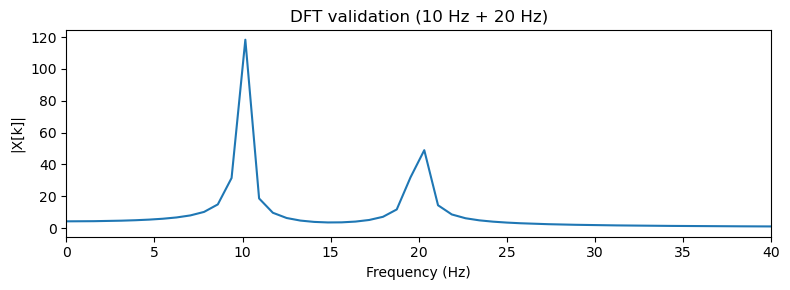

Phase at 10 Hz (0 deg): -2.176 rad
Phase at 10 Hz (90 deg): -0.634 rad


In [35]:
fs_test = 200.0
t = np.arange(0, 2.0, 1.0 / fs_test)
x_test = np.sin(2 * np.pi * 10.0 * t) + 0.5 * np.sin(2 * np.pi * 20.0 * t)
N_test = 256
x_test = x_test[:N_test]
X_test = dft_one_sided(x_test)
f_test = frequency_bins(N_test, fs_test, one_sided=True)

plt.figure(figsize=(8, 3))
plt.plot(f_test, np.abs(X_test))
plt.title('DFT validation (10 Hz + 20 Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('|X[k]|')
plt.xlim(0, 40)
plt.tight_layout()
plt.savefig(FIG_DIR / 'dft_validation_sine.png')
plt.show()

# phase shift test
x_phase = np.sin(2 * np.pi * 10.0 * t + np.pi / 2)
x_phase = x_phase[:N_test]
X_phase = dft_one_sided(x_phase)
idx_10 = int(np.argmin(np.abs(f_test - 10.0)))
print(f'Phase at 10 Hz (0 deg): {np.angle(X_test[idx_10]):.3f} rad')
print(f'Phase at 10 Hz (90 deg): {np.angle(X_phase[idx_10]):.3f} rad')

## 5) Windowing and normalization (known signals)

Windowed DFT: $X_w[k] = \sum x[n] w[n] e^{-j2\pi kn/N}$.
Normalization uses window energy $U = \sum w[n]^2$ so PSD has units of power/Hz:
$$\mathrm{PSD}(f_k) = \frac{|X_w[k]|^2}{f_s\,U}. $$

## 5.1) Leakage test (rectangular vs Hann)

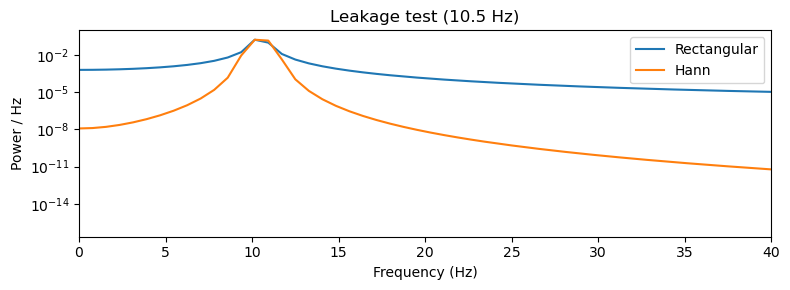

In [36]:
fs_demo = 200.0
N_leak = 256
f_leak = 10.5
t_leak = np.arange(0, N_leak) / fs_demo
x_leak = np.sin(2 * np.pi * f_leak * t_leak)
w_rect = get_window('rectangular', N_leak)
w_hann = get_window('hann', N_leak)
psd_rect, f_rect = periodogram(x_leak, fs_demo, w_rect)
psd_hann, f_hann = periodogram(x_leak, fs_demo, w_hann)

plt.figure(figsize=(8, 3))
plt.semilogy(f_rect, psd_rect, label='Rectangular')
plt.semilogy(f_hann, psd_hann, label='Hann')
plt.title('Leakage test (10.5 Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power / Hz')
plt.xlim(0, 40)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'leakage_test.png')
plt.show()

## 6) STFT from known signals

We validate STFT using a chirp before applying it to EEG.
Standard overlap is 50%: $H = N/2$.

## 6.1) Chirp validation (STFT correctness)

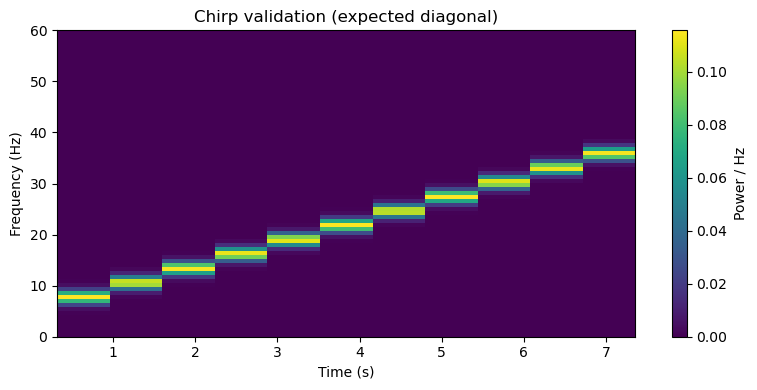

In [37]:
fs_demo = 200.0
t_chirp = np.arange(0, 8.0, 1.0 / fs_demo)
f0 = 5.0
f1 = 40.0
k = (f1 - f0) / t_chirp[-1]
phase = 2 * np.pi * (f0 * t_chirp + 0.5 * k * t_chirp ** 2)
x_chirp = np.sin(phase)

N_stft = 256
H_stft = N_stft // 2
psd_chirp, f_chirp, t_chirp_bins = stft_psd(
    x_chirp,
    fs_demo,
    nperseg=N_stft,
    hop=H_stft,
    window_name='hann',
)

plt.figure(figsize=(8, 4))
plt.pcolormesh(t_chirp_bins, f_chirp, psd_chirp.T, shading='auto')
plt.ylim(0, 60)
plt.title('Chirp validation (expected diagonal)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Power / Hz')
plt.tight_layout()
plt.savefig(FIG_DIR / 'chirp_validation.png')
plt.show()

## Phase 2: Application (EEG)

## 2) Load EEG (signal model)

We model $x[n] = s[n] + a[n] + \eta[n]$ and begin by loading a single channel from the EDF file.

In [38]:
preferred_channels = ["Cz", "O1", "O2", "Pz", "Fp1"]
x, fs, channel = load_channel_edf(
    DATA_PATH,
    preferred_channels=preferred_channels,
    duration_s=10.0,
)
print(f'Loaded {channel} with {x.size} samples at {fs:.2f} Hz ({x.size / fs:.2f}s)')

Loaded O1 with 2000 samples at 200.00 Hz (10.00s)


## 2.1) Sampling reality and power

Nyquist limit: $f_{Nyquist} = \frac{f_s}{2}$. Frequencies above this alias and are not physically trustworthy.

Power in DSP is variance: $P = x[n]^2$. It is not electrical power in watts.

## 3) DC removal (baseline drift)

DC offset is a non-physiological drift. Remove it before spectral analysis.

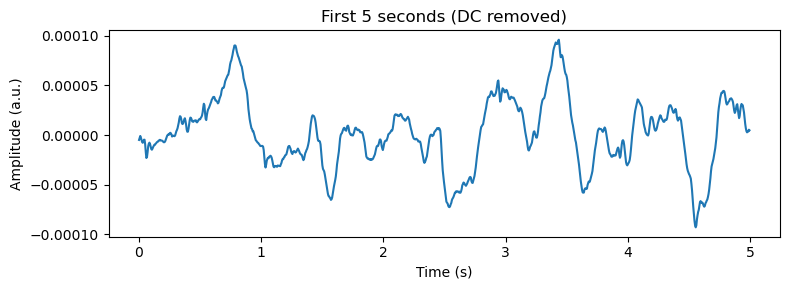

In [39]:
x = x - np.mean(x)

plt.figure(figsize=(8, 3))
plt.plot(np.arange(0, 5 * fs) / fs, x[: int(5 * fs)])
plt.title('First 5 seconds (DC removed)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (a.u.)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'time_domain_5s.png')
plt.show()

## 4) DFT on a single window (EEG inspection)

DFT measures how much of each frequency exists in a finite window. It assumes periodic extension; hence we will window next.

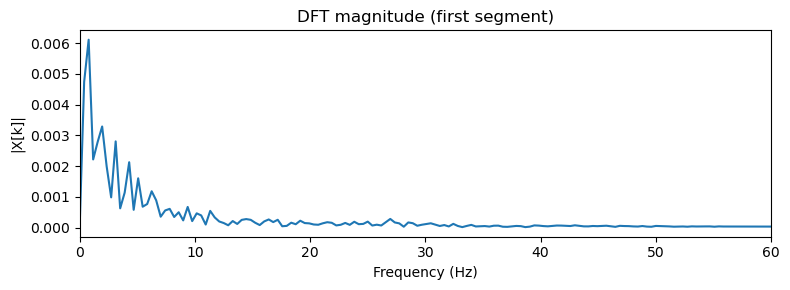

DC magnitude |X[0]|: 1.223704e-05
~50 Hz magnitude |X[k]|: 5.788206e-05 at 50.00 Hz


In [40]:
N = 512
segment = x[:N]
X = dft_one_sided(segment)
freqs = frequency_bins(N, fs, one_sided=True)

plt.figure(figsize=(8, 3))
plt.plot(freqs, np.abs(X))
plt.title('DFT magnitude (first segment)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('|X[k]|')
plt.xlim(0, 60)
plt.tight_layout()
plt.savefig(FIG_DIR / 'dft_magnitude.png')
plt.show()

dc_mag = abs(X[0])
idx_50 = int(np.argmin(np.abs(freqs - 50.0)))
mag_50 = abs(X[idx_50])
print(f'DC magnitude |X[0]|: {dc_mag:.6e}')
print(f'~50 Hz magnitude |X[k]|: {mag_50:.6e} at {freqs[idx_50]:.2f} Hz')

## 5) Windowed periodogram (EEG)

Windowed DFT: $X_w[k] = \sum x[n] w[n] e^{-j2\pi kn/N}$.
Normalization uses window energy $U = \sum w[n]^2$ so PSD has units of power/Hz:
$$\mathrm{PSD}(f_k) = \frac{|X_w[k]|^2}{f_s\,U}. $$

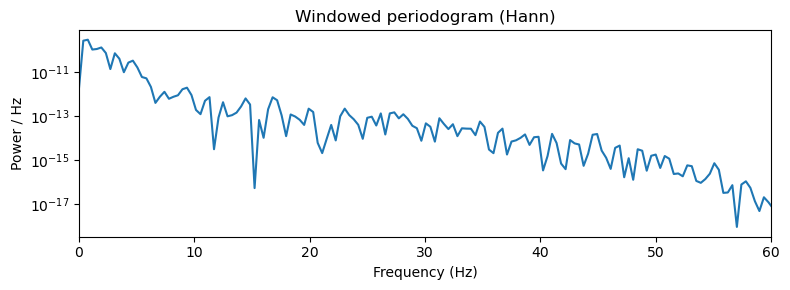

In [41]:
window = get_window('hann', N)
psd_seg, freqs = periodogram(segment, fs, window)

plt.figure(figsize=(8, 3))
plt.semilogy(freqs, psd_seg)
plt.title('Windowed periodogram (Hann)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power / Hz')
plt.xlim(0, 60)
plt.tight_layout()
plt.savefig(FIG_DIR / 'periodogram_hann.png')
plt.show()

## 6) STFT and PSD (EEG time-local spectra)

STFT uses a sliding window with hop size $H$. Standard overlap is 50%: $H = N/2$.
We compute PSD per frame and visualize the time-frequency energy.

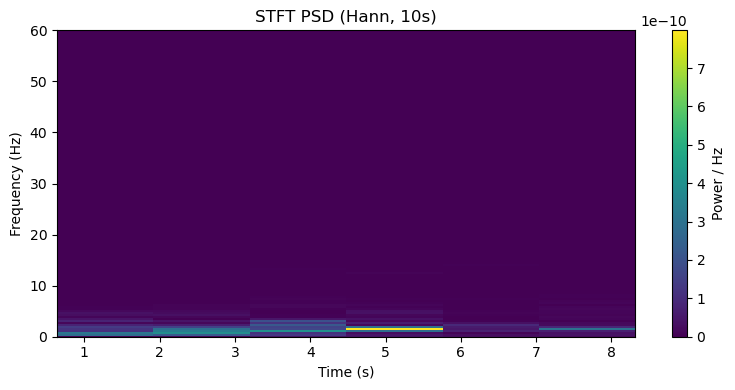

In [42]:
N = 512
H = N // 2
x_short = x

psd_frames, freqs, times = stft_psd(
    x_short,
    fs,
    nperseg=N,
    hop=H,
    window_name='hann',
)

plt.figure(figsize=(8, 4))
plt.pcolormesh(times, freqs, psd_frames.T, shading='auto')
plt.ylim(0, 60)
plt.title('STFT PSD (Hann, 10s)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Power / Hz')
plt.tight_layout()
plt.savefig(FIG_DIR / 'stft_psd.png')
plt.show()

## 7) Welch PSD (variance reduction)

Welch's method averages windowed periodograms across overlapping frames.

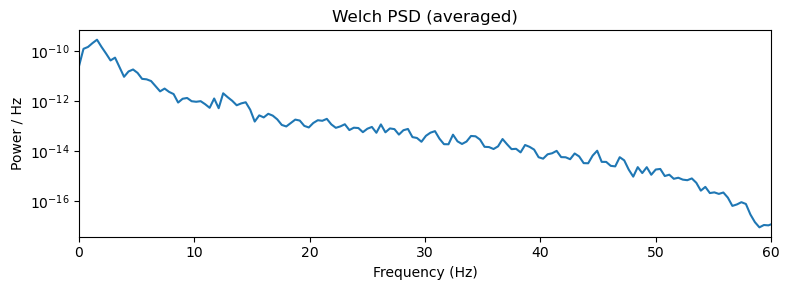

In [43]:
psd_avg = np.mean(psd_frames, axis=0)

plt.figure(figsize=(8, 3))
plt.semilogy(freqs, psd_avg)
plt.title('Welch PSD (averaged)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power / Hz')
plt.xlim(0, 60)
plt.tight_layout()
plt.savefig(FIG_DIR / 'welch_psd.png')
plt.show()

## 8) Band powers and artifact checks

In [44]:
def band_power(psd, freqs, band):
    f0, f1 = band
    mask = (freqs >= f0) & (freqs <= f1)
    if not np.any(mask):
        return 0.0
    return float(np.trapezoid(psd[mask], freqs[mask]))

gamma_high = min(100.0, freqs[-1])
bands = {
    'delta': (0.0, 4.0),
    'theta': (4.0, 8.0),
    'alpha': (8.0, 13.0),
    'beta': (13.0, 30.0),
    'gamma': (30.0, gamma_high),
}

band_powers = {name: band_power(psd_avg, freqs, b) for name, b in bands.items()}
for name, p in band_powers.items():
    print(f'{name}: {p:.6e}')

# artifact checks: powerline (50/60 Hz) and 83 Hz stability
powerline_50 = band_power(psd_avg, freqs, (49.0, 51.0))
powerline_60 = band_power(psd_avg, freqs, (59.0, 61.0))
band_83 = band_power(psd_avg, freqs, (82.0, 84.0))
idx_83 = int(np.argmin(np.abs(freqs - 83.0)))
p83_series = psd_frames[:, idx_83] if idx_83 < psd_frames.shape[1] else np.array([])
p83_mean = float(np.mean(p83_series)) if p83_series.size else 0.0
p83_std = float(np.std(p83_series)) if p83_series.size else 0.0
print(f'Powerline 50 Hz band power: {powerline_50:.6e}')
print(f'Powerline 60 Hz band power: {powerline_60:.6e}')
print(f'83 Hz band power: {band_83:.6e}')
print(f'83 Hz stability (mean/std): {p83_mean:.6e} / {p83_std:.6e}')

delta: 4.438902e-10
theta: 2.833414e-11
alpha: 5.217185e-12
beta: 3.111025e-12
gamma: 3.197306e-13
Powerline 50 Hz band power: 2.610209e-15
Powerline 60 Hz band power: 1.812979e-17
83 Hz band power: 9.175518e-16
83 Hz stability (mean/std): 1.885804e-16 / 1.973830e-16
